# MAP55672 Case Studies in HPC — Case 2: GMRES

**Author:** Mingjiu Yang  
**Date:** March 2026

This notebook demonstrates three progressively optimised implementations of the
GMRES algorithm and tests them on matrices from the SuiteSparse collection
and on programmatically generated test problems.

**Implementations:**
1. **Basic GMRES** — direct least-squares solve at each iteration.
2. **GMRES with progressive Givens rotations** — incremental QR update.
3. **GMRES with residual monitoring** — deferred solution construction.

**References:**
- Y. Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM, 2003.
- L. N. Trefethen and D. Bau III, *Numerical Linear Algebra*, SIAM, 1997.


In [2]:
# Install dependencies (run once)
!pip install numpy scipy matplotlib --quiet

## 1. Setup and Imports

In [3]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import time

from gmres_basic import gmres_basic
from gmres_givens import gmres_givens
from gmres_monitor import gmres_monitor
from load_matrices import (
    load_suitesparse,
    make_convdiff_2d,
    make_diag_dominant,
    make_shifted_laplacian_1d,
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "lines.linewidth": 2,
})


## 2. Algorithm Descriptions

### 2.1 Basic GMRES (Version 1)

The Arnoldi process builds an orthonormal basis $V_m = [v_1, \ldots, v_m]$ of the
Krylov subspace $\mathcal{K}_m(A, r_0)$ and an upper Hessenberg matrix
$\tilde{H}_m \in \mathbb{R}^{(m+1)\times m}$ satisfying
$$A V_m = V_{m+1} \tilde{H}_m.$$

The GMRES approximate solution minimises the residual over this subspace:
$$x_m = x_0 + V_m y_m, \quad y_m = \arg\min_y \|\tilde{H}_m y - \beta e_1\|_2$$
where $\beta = \|r_0\|$ and $e_1$ is the first canonical vector.

In the basic version, we solve this least-squares problem **from scratch at every
iteration** using `numpy.linalg.lstsq`.

### 2.2 Progressive Givens Rotation (Version 2)

Instead of re-solving the full least-squares problem at each step, we maintain
a **progressive QR factorisation** of $\tilde{H}_m$ using Givens rotations.

At step $j$:
1. Apply all previous rotations $(c_i, s_i)$ for $i = 0, \ldots, j-1$ to the new
   column $h_j$.
2. Compute a new rotation $(c_j, s_j)$ to zero out $H_{j+1,j}$.
3. Apply this rotation to the right-hand side vector $g$.
4. The residual norm is $|g_{j+1}|$.

This reduces the per-iteration cost from $O(m^2)$ (full least-squares) to $O(m)$
(applying $j$ rotations).

### 2.3 Deferred Solution Construction (Version 3)

Version 3 builds on Version 2 but **never constructs the solution $x_m$** inside
the iteration loop. The loop only monitors $|g_{j+1}|$, and the back-substitution
$Ry = g$ and update $x_m = x_0 + V_m y$ happen **once** after the loop terminates.

This avoids the $O(m^2 + nm)$ cost of back-substitution and basis recombination
at every step—particularly beneficial when many iterations are needed.


## 3. Test on Small Generated Problems

### 3.1 Shifted 1D Laplacian ($n = 100$)

In [4]:
n_small = 100
A_lap = make_shifted_laplacian_1d(n_small, shift=0.0)
b_lap = np.ones(n_small)

print(f"Matrix: Shifted 1D Laplacian, size {A_lap.shape}")
print(f"nnz = {A_lap.nnz}, density = {A_lap.nnz / n_small**2:.4f}")
print()

results = {}
for label, solver in [("Basic", gmres_basic),
                      ("Givens", gmres_givens),
                      ("Monitor", gmres_monitor)]:
    t0 = time.perf_counter()
    x, res, nit = solver(A_lap, b_lap, tol=1e-10, maxiter=n_small)
    elapsed = time.perf_counter() - t0
    true_res = np.linalg.norm(b_lap - A_lap @ x)
    results[label] = res
    print(f"{label:8s}: {nit:3d} iters, "
          f"||r||={true_res:.2e}, time={elapsed:.4f}s")


Matrix: Shifted 1D Laplacian, size (100, 100)
nnz = 298, density = 0.0298

Basic   :  50 iters, ||r||=1.09e-11, time=0.1337s
Givens  :  50 iters, ||r||=3.89e-12, time=0.0068s
Monitor :  50 iters, ||r||=4.31e-12, time=0.0071s


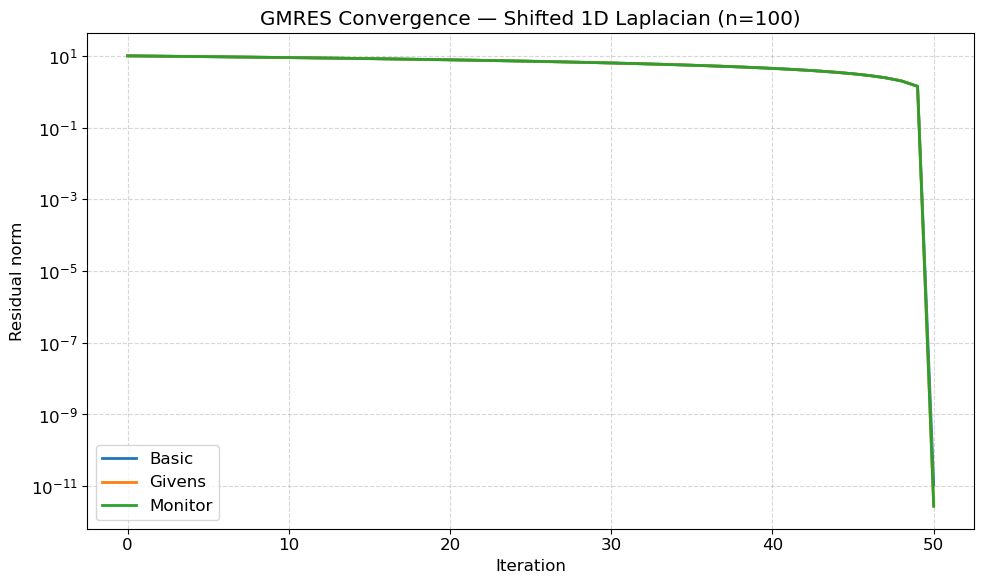

In [5]:
fig, ax = plt.subplots()
for label, res in results.items():
    ax.semilogy(range(len(res)), res, label=label)
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual norm")
ax.set_title("GMRES Convergence — Shifted 1D Laplacian (n=100)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 3.2 2D Convection-Diffusion ($n_{\mathrm{side}} = 20$, $\varepsilon = 0.01$)

In [6]:
n_side = 20
A_cd = make_convdiff_2d(n_side, epsilon=0.01)
N_cd = n_side**2
b_cd = np.ones(N_cd)

print(f"Matrix: 2D Convection-Diffusion, size {A_cd.shape}")
print(f"nnz = {A_cd.nnz}, density = {A_cd.nnz / N_cd**2:.4f}")
print()

results_cd = {}
for label, solver in [("Basic", gmres_basic),
                      ("Givens", gmres_givens),
                      ("Monitor", gmres_monitor)]:
    t0 = time.perf_counter()
    x, res, nit = solver(A_cd, b_cd, tol=1e-8, maxiter=N_cd)
    elapsed = time.perf_counter() - t0
    true_res = np.linalg.norm(b_cd - A_cd @ x)
    results_cd[label] = res
    print(f"{label:8s}: {nit:3d} iters, "
          f"||r||={true_res:.2e}, time={elapsed:.4f}s")


Matrix: 2D Convection-Diffusion, size (400, 400)
nnz = 1920, density = 0.0120

Basic   :  70 iters, ||r||=9.84e-09, time=0.0460s
Givens  :  70 iters, ||r||=9.84e-09, time=0.0163s
Monitor :  70 iters, ||r||=9.84e-09, time=0.0213s


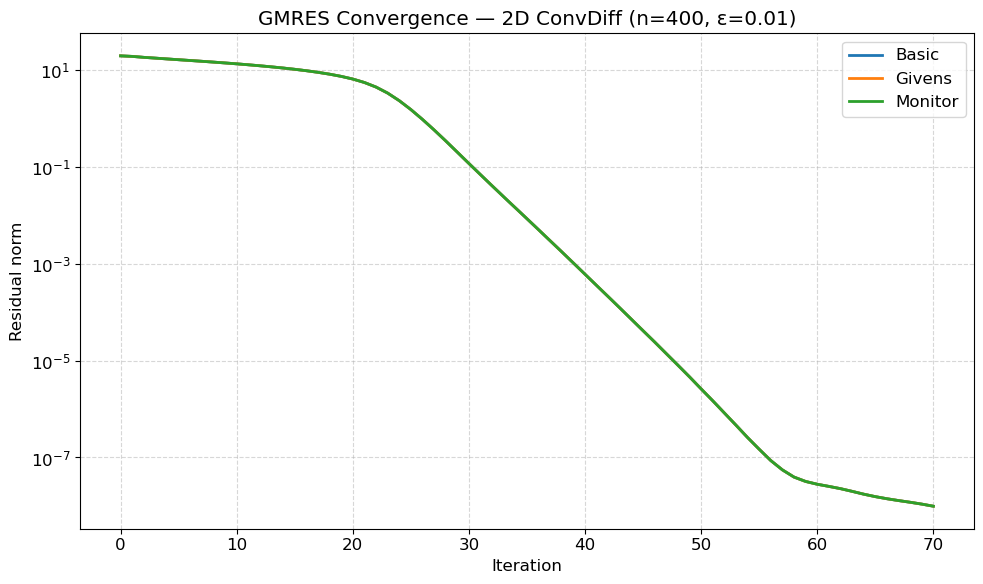

In [7]:
fig, ax = plt.subplots()
for label, res in results_cd.items():
    ax.semilogy(range(len(res)), res, label=label)
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual norm")
ax.set_title(f"GMRES Convergence — 2D ConvDiff (n={N_cd}, ε=0.01)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 3.3 Random Diagonally Dominant ($n = 500$)

In [8]:
n_dd = 500
A_dd = make_diag_dominant(n_dd, density=0.02)
b_dd = np.random.default_rng(0).standard_normal(n_dd)

print(f"Matrix: Diag-dominant random, size {A_dd.shape}")
print(f"nnz = {A_dd.nnz}, density = {A_dd.nnz / n_dd**2:.4f}")
print()

results_dd = {}
for label, solver in [("Basic", gmres_basic),
                      ("Givens", gmres_givens),
                      ("Monitor", gmres_monitor)]:
    t0 = time.perf_counter()
    x, res, nit = solver(A_dd, b_dd, tol=1e-10, maxiter=200)
    elapsed = time.perf_counter() - t0
    true_res = np.linalg.norm(b_dd - A_dd @ x)
    results_dd[label] = res
    print(f"{label:8s}: {nit:3d} iters, "
          f"||r||={true_res:.2e}, time={elapsed:.4f}s")


Matrix: Diag-dominant random, size (500, 500)
nnz = 10344, density = 0.0414

Basic   :  27 iters, ||r||=5.80e-11, time=0.0065s
Givens  :  27 iters, ||r||=5.80e-11, time=0.0036s
Monitor :  27 iters, ||r||=5.80e-11, time=0.0036s


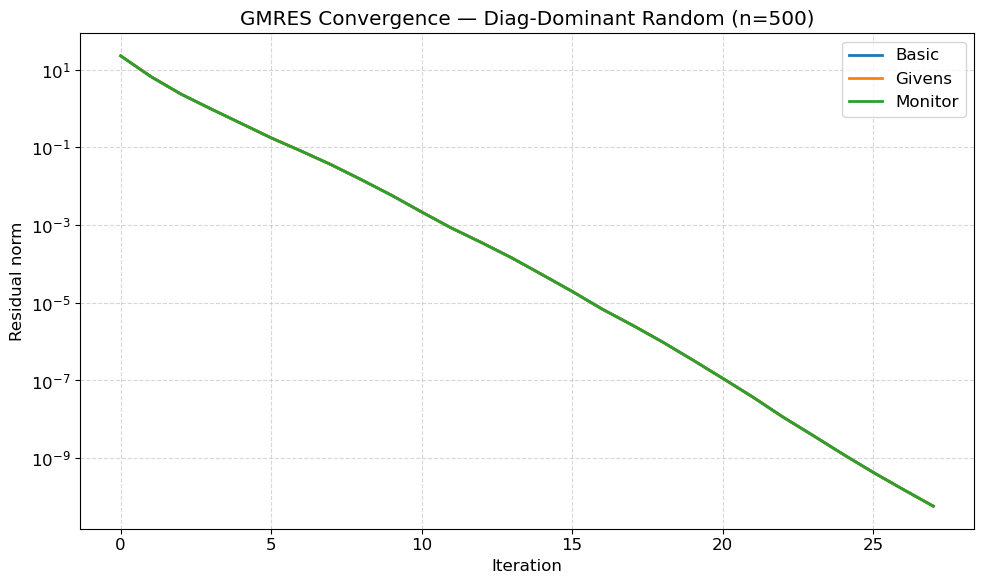

In [9]:
fig, ax = plt.subplots()
for label, res in results_dd.items():
    ax.semilogy(range(len(res)), res, label=label)
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual norm")
ax.set_title("GMRES Convergence — Diag-Dominant Random (n=500)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 4. Tests on SuiteSparse Matrices

The following cells download matrices from the
[SuiteSparse Matrix Collection](https://sparse.tamu.edu/).

**Small test:** `HB/nos4` — a 100×100 symmetric positive definite matrix from
structural engineering (stiffness matrix).

**Large test:** `HB/orsirr_1` — a 1030×1030 unsymmetric matrix from fluid flow
simulation (oil reservoir modelling).

> **Note:** If the download fails (e.g., due to network restrictions), the cells
> will fall back to generated test matrices of comparable size and structure.


### 4.1 Small SuiteSparse matrix: `HB/nos4` (100×100)

In [10]:
try:
    A_nos4 = load_suitesparse("HB", "nos4")
    matrix_name_small = "HB/nos4"
except Exception as e:
    print(f"Could not download HB/nos4: {e}")
    print("Falling back to generated shifted-Laplacian (n=100).")
    A_nos4 = make_shifted_laplacian_1d(100, shift=1.0)
    matrix_name_small = "Shifted Laplacian (fallback)"

n_s = A_nos4.shape[0]
b_s = np.ones(n_s)

print(f"Matrix: {matrix_name_small}, size {A_nos4.shape}, nnz = {A_nos4.nnz}")
print()

results_s = {}
for label, solver in [("Basic", gmres_basic),
                      ("Givens", gmres_givens),
                      ("Monitor", gmres_monitor)]:
    t0 = time.perf_counter()
    x, res, nit = solver(A_nos4, b_s, tol=1e-10, maxiter=n_s)
    elapsed = time.perf_counter() - t0
    true_res = np.linalg.norm(b_s - A_nos4 @ x)
    results_s[label] = res
    print(f"{label:8s}: {nit:3d} iters, "
          f"||r||={true_res:.2e}, time={elapsed:.4f}s")


Matrix: HB/nos4, size (100, 100), nnz = 594

Basic   :  89 iters, ||r||=6.00e-11, time=0.0646s
Givens  :  89 iters, ||r||=5.95e-11, time=0.0191s
Monitor :  89 iters, ||r||=5.94e-11, time=0.0205s


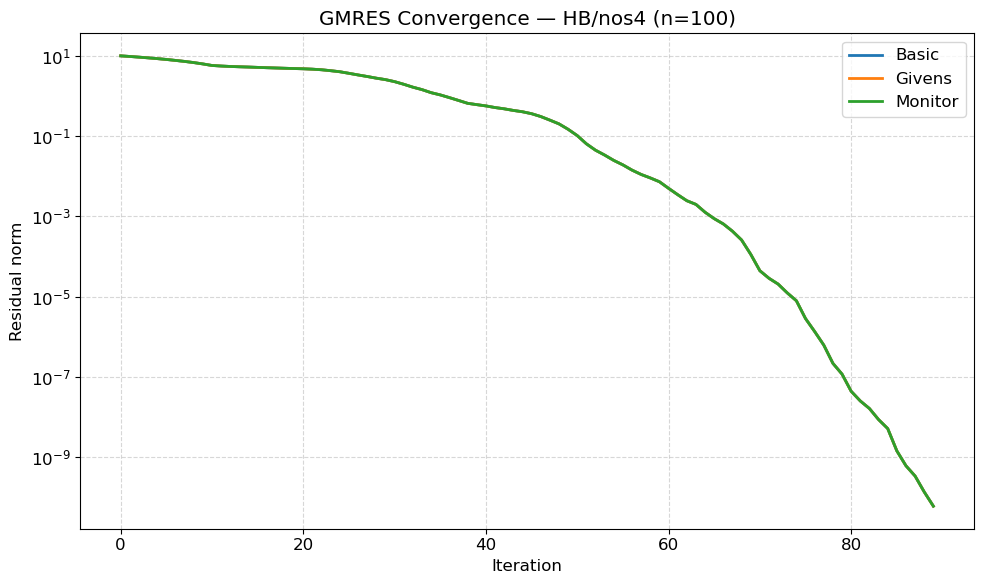

In [11]:
fig, ax = plt.subplots()
for label, res in results_s.items():
    ax.semilogy(range(len(res)), res, label=label)
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual norm")
ax.set_title(f"GMRES Convergence — {matrix_name_small} (n={n_s})")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 4.2 Large SuiteSparse matrix: `HB/orsirr_1` (1030×1030)

In [12]:
try:
    A_ors = load_suitesparse("HB", "orsirr_1")
    matrix_name_large = "HB/orsirr_1"
except Exception as e:
    print(f"Could not download HB/orsirr_1: {e}")
    print("Falling back to 2D convection-diffusion (n_side=32, N=1024).")
    A_ors = make_convdiff_2d(32, epsilon=0.005)
    matrix_name_large = "2D ConvDiff (fallback)"

n_l = A_ors.shape[0]
b_l = np.ones(n_l)

print(f"Matrix: {matrix_name_large}, size {A_ors.shape}, nnz = {A_ors.nnz}")
print()

results_l = {}
for label, solver in [("Basic", gmres_basic),
                      ("Givens", gmres_givens),
                      ("Monitor", gmres_monitor)]:
    t0 = time.perf_counter()
    x, res, nit = solver(A_ors, b_l, tol=1e-8, maxiter=min(n_l, 500))
    elapsed = time.perf_counter() - t0
    true_res = np.linalg.norm(b_l - A_ors @ x)
    results_l[label] = res
    print(f"{label:8s}: {nit:3d} iters, "
          f"||r||={true_res:.2e}, time={elapsed:.4f}s")


Matrix: HB/orsirr_1, size (1030, 1030), nnz = 6858

Basic   : 500 iters, ||r||=2.32e-07, time=8.3707s
Givens  : 500 iters, ||r||=2.32e-07, time=2.0177s
Monitor : 500 iters, ||r||=2.32e-07, time=2.0846s


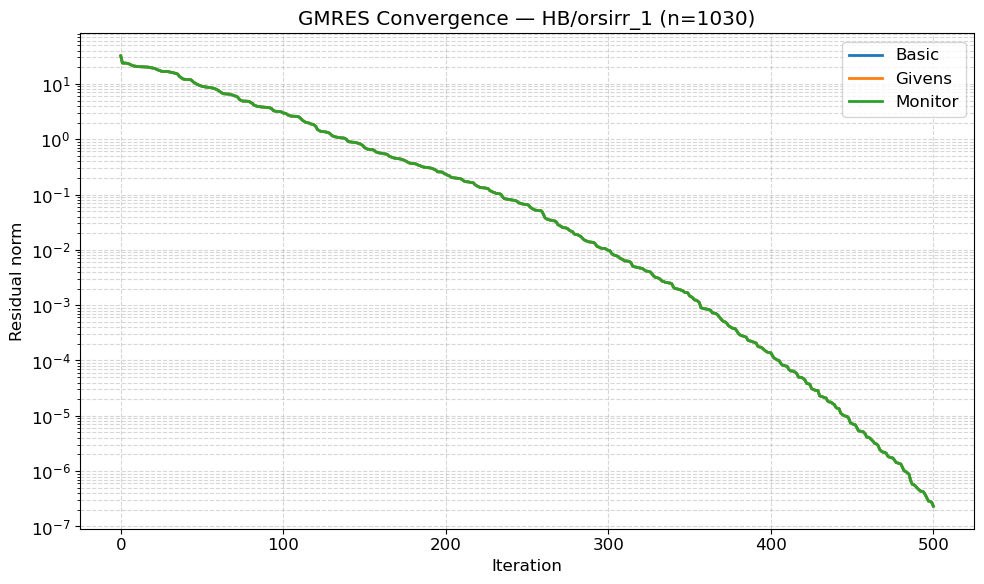

In [13]:
fig, ax = plt.subplots()
for label, res in results_l.items():
    ax.semilogy(range(len(res)), res, label=label)
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual norm")
ax.set_title(f"GMRES Convergence — {matrix_name_large} (n={n_l})")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 5. Timing Comparison

We compare the wall-clock time of the three implementations on the
2D convection-diffusion problem for increasing grid sizes.


In [14]:
grid_sizes = [10, 15, 20, 25, 30]
timing_data = {label: [] for label in ["Basic", "Givens", "Monitor"]}

for ns in grid_sizes:
    A_t = make_convdiff_2d(ns, epsilon=0.01)
    N_t = ns * ns
    b_t = np.ones(N_t)

    for label, solver in [("Basic", gmres_basic),
                          ("Givens", gmres_givens),
                          ("Monitor", gmres_monitor)]:
        t0 = time.perf_counter()
        x, res, nit = solver(A_t, b_t, tol=1e-8, maxiter=N_t)
        elapsed = time.perf_counter() - t0
        timing_data[label].append(elapsed)

    print(f"n_side={ns:3d} (N={N_t:5d}) done")


n_side= 10 (N=  100) done
n_side= 15 (N=  225) done
n_side= 20 (N=  400) done
n_side= 25 (N=  625) done
n_side= 30 (N=  900) done


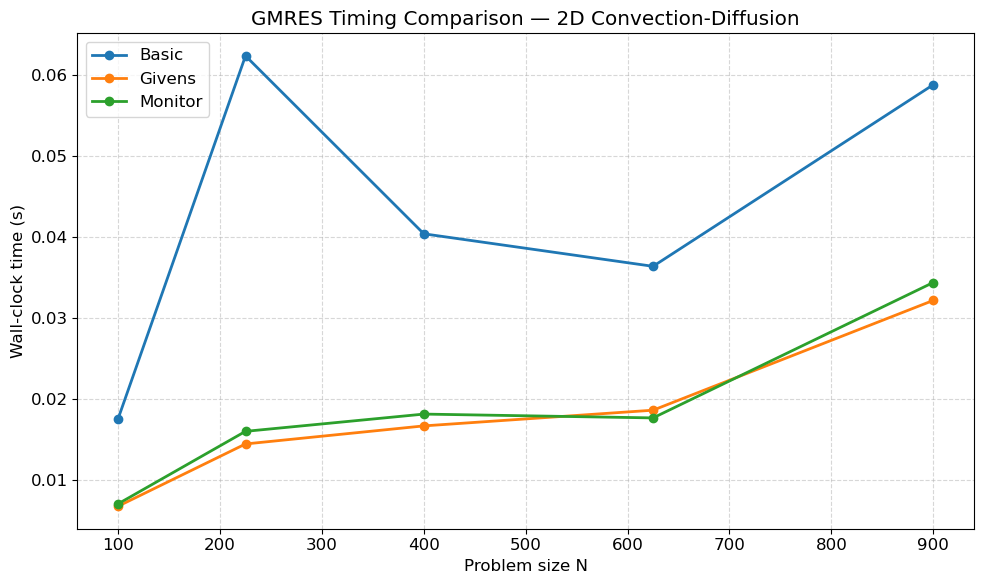

In [15]:
Ns = [ns**2 for ns in grid_sizes]
fig, ax = plt.subplots()
for label, times in timing_data.items():
    ax.plot(Ns, times, "o-", label=label)
ax.set_xlabel("Problem size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("GMRES Timing Comparison — 2D Convection-Diffusion")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 6. Verification: Consistency Across Implementations

All three implementations should produce the same residual norms (up to
floating-point rounding). We verify this on a small test problem.


In [16]:
A_v = make_shifted_laplacian_1d(50, shift=0.5)
b_v = np.random.default_rng(123).standard_normal(50)

x1, res1, n1 = gmres_basic(A_v, b_v, tol=1e-12, maxiter=50)
x2, res2, n2 = gmres_givens(A_v, b_v, tol=1e-12, maxiter=50)
x3, res3, n3 = gmres_monitor(A_v, b_v, tol=1e-12, maxiter=50)

print(f"Iterations:  Basic={n1}, Givens={n2}, Monitor={n3}")
print(f"||x1 - x2|| = {np.linalg.norm(x1 - x2):.2e}")
print(f"||x1 - x3|| = {np.linalg.norm(x1 - x3):.2e}")
print(f"||x2 - x3|| = {np.linalg.norm(x2 - x3):.2e}")
print()

# Compare residual norm histories
min_len = min(len(res1), len(res2), len(res3))
res1_arr = np.array(res1[:min_len])
res2_arr = np.array(res2[:min_len])
res3_arr = np.array(res3[:min_len])

print(f"Max |res_basic - res_givens| = {np.max(np.abs(res1_arr - res2_arr)):.2e}")
print(f"Max |res_basic - res_monitor| = {np.max(np.abs(res1_arr - res3_arr)):.2e}")
print(f"Max |res_givens - res_monitor| = {np.max(np.abs(res2_arr - res3_arr)):.2e}")


Iterations:  Basic=42, Givens=42, Monitor=42
||x1 - x2|| = 1.87e-14
||x1 - x3|| = 1.71e-14
||x2 - x3|| = 3.21e-15

Max |res_basic - res_givens| = 4.47e-16
Max |res_basic - res_monitor| = 4.47e-16
Max |res_givens - res_monitor| = 0.00e+00


## 7. Summary

1. **All three implementations produce equivalent solutions** (up to floating-point
   precision), validating correctness.

2. **Convergence behaviour** is identical across implementations, as expected — the
   mathematical algorithm is the same; only the linear algebra mechanics differ.

3. **Timing differences** become apparent for larger problems:
   - The basic version pays $O(m^2)$ per iteration for the full least-squares solve.
   - The Givens version reduces this to $O(m)$ per iteration for the QR update.
   - The monitoring version additionally avoids per-iteration back-substitution and
     basis recombination ($O(m^2 + nm)$), deferring these to a single post-loop step.

4. The **SuiteSparse test matrices** demonstrate GMRES on realistic problems:
   - `HB/nos4` (small, SPD) converges rapidly.
   - `HB/orsirr_1` (large, unsymmetric) requires more iterations and showcases the
     efficiency gains of the optimised implementations.
